In [18]:
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"

import torch
torch.set_num_threads(1)

import multiprocessing as mp
import numpy as np

from EffectiveFreqDamp0T import run_simulation

# -----------------------------
# SETTINGS
# -----------------------------
NUM_TRIALS_PER_FREQ = 200
NUM_PROCESSES = 10

if __name__ == "__main__":
    try:
        mp.set_start_method("spawn")
    except RuntimeError:
        pass

    length = 50.0
    width = 2.0
    peddamp = 0.30
    pedBodyF = 3.10
    beamdamp = np.array([0.005])
    Tocity = 10
    Outcity = 10

    # safer than starting at 0.0
    bridge_freq_values = np.arange(0.001, 5.0 + 1e-9, 0.25)

    np.random.seed()

    all_eff_damping = []
    all_eff_frequency = []
    all_mass_ratio = []
    all_numped = []

    for bf in bridge_freq_values:
        beamFreq = np.array([bf])

        seeds = [np.random.randint(0, 2**31 - 1) for _ in range(NUM_TRIALS_PER_FREQ)]
        args_list = [
            (seed, peddamp, pedBodyF, beamFreq, beamdamp, Tocity, Outcity, length, width)
            for seed in seeds
        ]

        with mp.get_context("spawn").Pool(processes=NUM_PROCESSES) as pool:
            results = pool.map(run_simulation, args_list)

        t_all, eff_damping_all, eff_frequency_all, mass_ratio_all, numped_all = zip(*results)

        # same time vector for all trials at this frequency
        t = t_all[0]

        all_eff_damping.append(np.array(eff_damping_all))
        all_eff_frequency.append(np.array(eff_frequency_all))
        all_mass_ratio.append(np.array(mass_ratio_all))
        all_numped.append(np.array(numped_all))

        print(f"Done beam frequency = {bf:.2f} Hz")

    # shape: (n_freqs, n_trials)
    all_eff_damping = np.array(all_eff_damping)
    all_eff_frequency = np.array(all_eff_frequency)
    all_mass_ratio = np.array(all_mass_ratio)
    all_numped = np.array(all_numped)

    print("\nCompleted all bridge frequencies.")
    print("bridge_freq_values shape:", bridge_freq_values.shape)
    print("all_eff_damping shape:", all_eff_damping.shape)
    print("all_eff_frequency shape:", all_eff_frequency.shape)
    print("all_mass_ratio shape:", all_mass_ratio.shape)
    print("all_numped shape:", all_numped.shape)

Done beam frequency = 0.00 Hz
Done beam frequency = 0.25 Hz
Done beam frequency = 0.50 Hz
Done beam frequency = 0.75 Hz
Done beam frequency = 1.00 Hz
Done beam frequency = 1.25 Hz
Done beam frequency = 1.50 Hz
Done beam frequency = 1.75 Hz
Done beam frequency = 2.00 Hz
Done beam frequency = 2.25 Hz
Done beam frequency = 2.50 Hz
Done beam frequency = 2.75 Hz
Done beam frequency = 3.00 Hz
Done beam frequency = 3.25 Hz
Done beam frequency = 3.50 Hz
Done beam frequency = 3.75 Hz
Done beam frequency = 4.00 Hz
Done beam frequency = 4.25 Hz
Done beam frequency = 4.50 Hz
Done beam frequency = 4.75 Hz

Completed all bridge frequencies.
bridge_freq_values shape: (20,)
all_eff_damping shape: (20, 200, 1)
all_eff_frequency shape: (20, 200, 1)
all_mass_ratio shape: (20, 200)
all_numped shape: (20, 200)


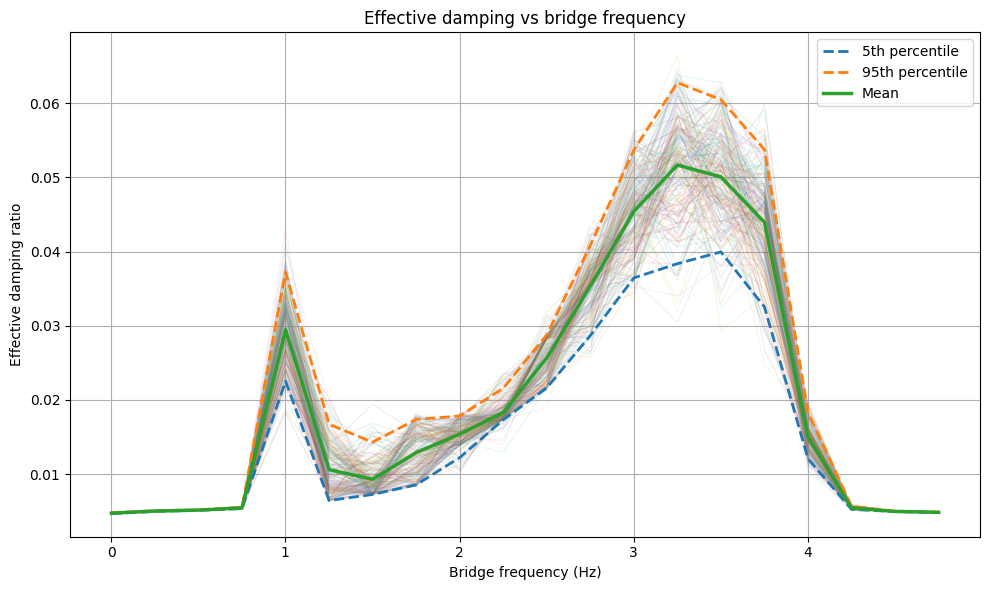

C:\Users\slok0019\AppData\Local\Temp\ipykernel_30124\3397565638.py:48: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


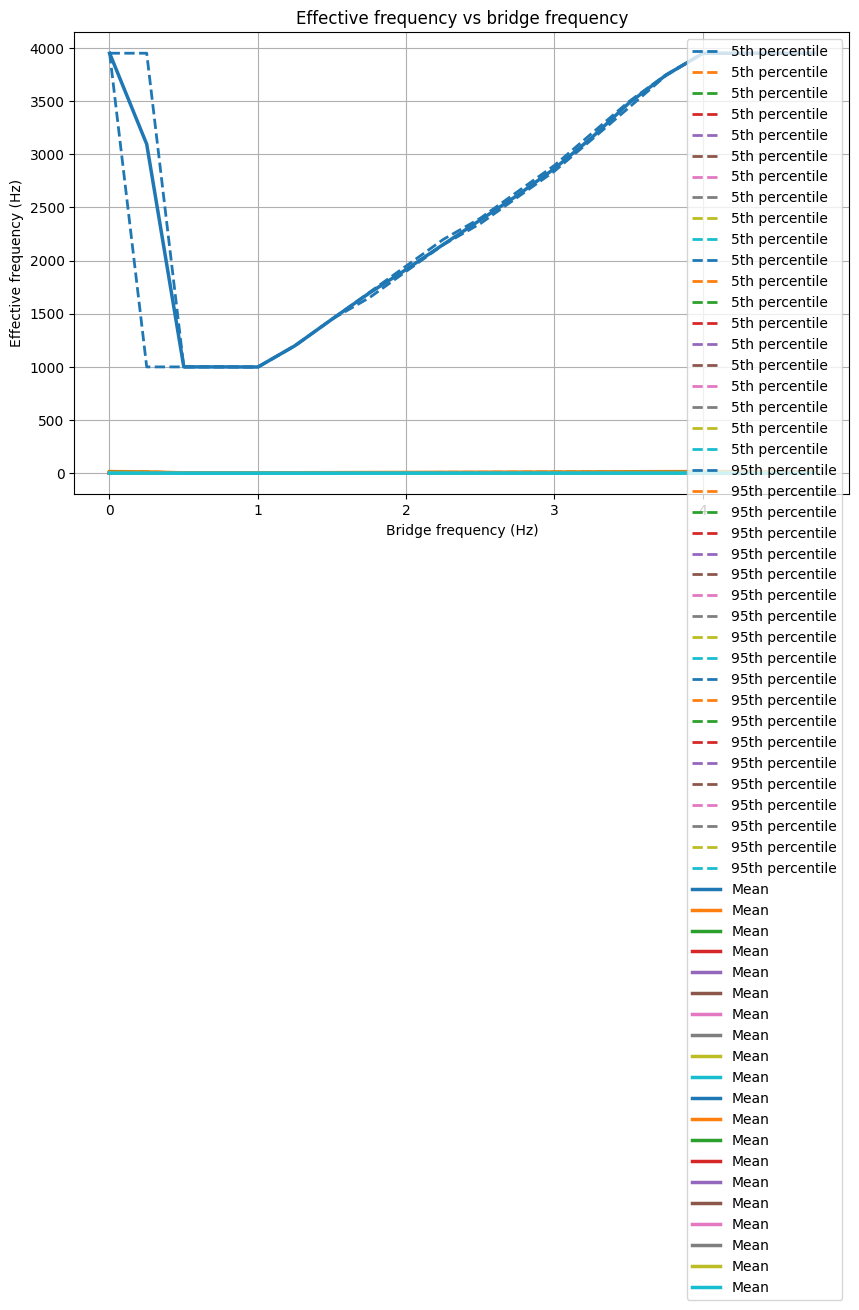

In [19]:
import numpy as np
import matplotlib.pyplot as plt

# statistics across trials
mean_eff_damping = np.mean(all_eff_damping, axis=1)
p5_eff_damping   = np.percentile(all_eff_damping, 5, axis=1)
p95_eff_damping  = np.percentile(all_eff_damping, 95, axis=1)

plt.figure(figsize=(10, 6))

# cloud: each trial as a faint line
for j in range(all_eff_damping.shape[1]):
    plt.plot(bridge_freq_values, all_eff_damping[:, j], alpha=0.12, linewidth=0.8)

# percentile bounds
plt.plot(bridge_freq_values, p5_eff_damping, linestyle='--', linewidth=2, label='5th percentile')
plt.plot(bridge_freq_values, p95_eff_damping, linestyle='--', linewidth=2, label='95th percentile')

# mean
plt.plot(bridge_freq_values, mean_eff_damping, linewidth=2.5, label='Mean')

plt.xlabel("Bridge frequency (Hz)")
plt.ylabel("Effective damping ratio")
plt.title("Effective damping vs bridge frequency")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

mean_eff_frequency = np.mean(all_eff_frequency, axis=1)
p5_eff_frequency   = np.percentile(all_eff_frequency, 5, axis=1)
p95_eff_frequency  = np.percentile(all_eff_frequency, 95, axis=1)

plt.figure(figsize=(10, 6))

for j in range(all_eff_frequency.shape[1]):
    plt.plot(bridge_freq_values, all_eff_frequency[:, j], alpha=0.12, linewidth=0.8)

plt.plot(bridge_freq_values, p5_eff_frequency/bridge_freq_values, linestyle='--', linewidth=2, label='5th percentile')
plt.plot(bridge_freq_values, p95_eff_frequency/bridge_freq_values, linestyle='--', linewidth=2, label='95th percentile')
plt.plot(bridge_freq_values, mean_eff_frequency/bridge_freq_values, linewidth=2.5, label='Mean')

plt.xlabel("Bridge frequency (Hz)")
plt.ylabel("Effective frequency (Hz)")
plt.title("Effective frequency vs bridge frequency")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

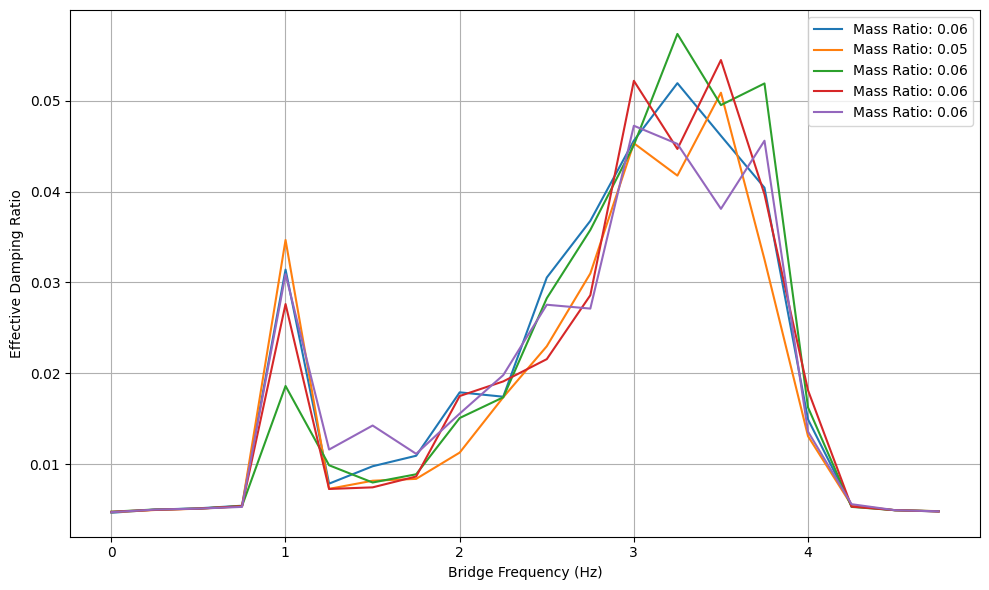

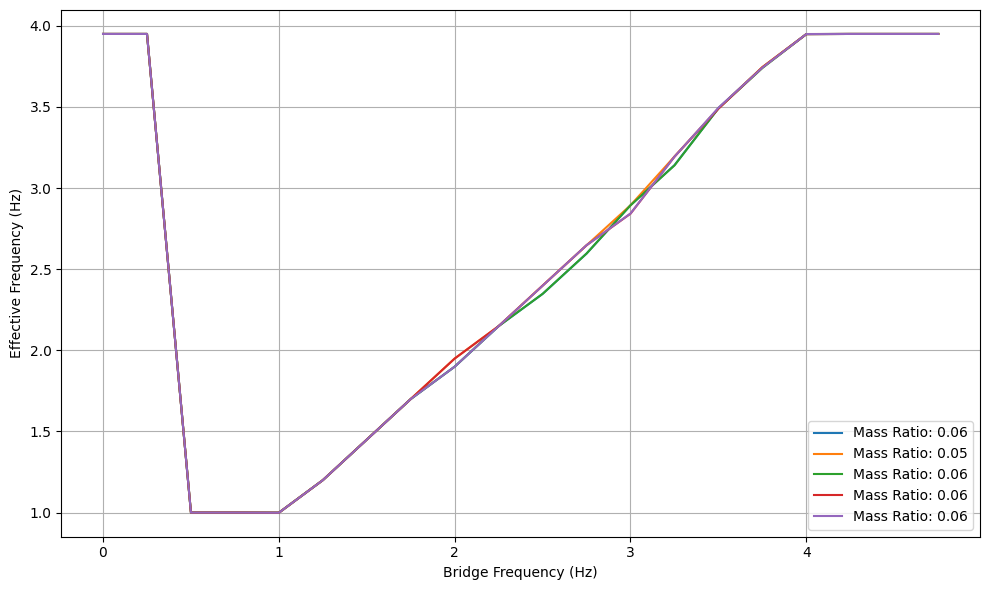

In [20]:
import matplotlib.pyplot as plt
import numpy as np

# choose 5 trials to display
trial_ids = [0, 1, 2, 3, 4]

plt.figure(figsize=(10, 6))
for j in trial_ids:
    mass_ratio_label = np.mean(all_mass_ratio[:, j])   # average over BridgeFreq
    plt.plot(
        bridge_freq_values,
        all_eff_damping[:, j],
        label=f"Mass Ratio: {mass_ratio_label:.2f}"
    )

plt.ylabel("Effective Damping Ratio")
plt.xlabel("Bridge Frequency (Hz)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


plt.figure(figsize=(10, 6))
for j in trial_ids:
    mass_ratio_label = np.mean(all_mass_ratio[:, j])
    plt.plot(
        bridge_freq_values,
        all_eff_frequency[:, j],
        label=f"Mass Ratio: {mass_ratio_label:.2f}"
    )

plt.ylabel("Effective Frequency (Hz)")
plt.xlabel("Bridge Frequency (Hz)")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()